<a href="https://colab.research.google.com/github/PriscillaTiara/-COMPVI-MIDTERM_TASK_Priscilla_Tiara-4222301026-/blob/main/MIDTERM_PriscillaTiaraS_4222301026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MIDTERM ASSIGMENTS

Name : Priscilla Tiara S

Stud Num : 4222301026

Class : RE 6 A

Import All libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print('all ready!')

all ready!


#1. Data preparation
load dataset :

In [ ]:
df = pd.read_csv('emnist-letters-train.csv', header=None)

print('dataset all load')

dataset all load


Because the first coloumn was a alphabets, so we delete 1 to make it A=0, B=1,...,Z=25

In [ ]:
labels = df.iloc[:, 0].values - 1

The 1-784 coloumn is a pixel data. so we build up again the array data which is 28x28.
to make all the lines become a box image, not a row of long numbers.

In [ ]:
images = df.iloc[:, 1:].values.reshape(-1, 28, 28).astype(np.uint8)

EMIST saves picture in reverse and rotated orientation. So that we need to rotate the alphabet so that it will be normal/

In [ ]:
images = np.array([np.fliplr(np.rot90(img)) for img in images])

print(f'Jumlah gambar : {images.shape[0]}')
print(f'Ukuran gambar : {images.shape[1]}x{images.shape[2]} piksel')
print(f'Jumlah kelas  : {len(np.unique(labels))} (0=A sampai 25=Z)')

Jumlah gambar : 88800
Ukuran gambar : 28x28 piksel
Jumlah kelas  : 26 (0=A sampai 25=Z)


#2.Balanced sampling
- take 2.600 set
- every class has 100 dataset

In [ ]:
from re import X
np.random.seed(42)

X_list, y_list = [], []

#LOOP AND SHUFFLE DATASET
for cls in range(26):  # loop from class 0 (A) until 25(z)
    idx = np.where(labels == cls)[0]   # LOOK for everypicture index with = cls
    np.random.shuffle(idx)             # shuffle the arrangments so there will be no options being same
    X_list.append(images[idx[:100]])   # take the first 100 data
    y_list.append(np.full(100, cls))   #  make 100 label with cls data

#combine all class into one big array
X = np.concatenate(X_list)  # shape: (2600, 28, 28)
y = np.concatenate(y_list)  # shape (2600,)

In [ ]:
#SHUFFLES ALL DATA FROM A TO Z
idx_shuffle = np.random.permutation(len(X))
X, y = X[idx_shuffle], y[idx_shuffle]

print(f'Total sampel setelah sampling: {len(X)}')
print(f'Sampel per kelas: {np.unique(y, return_counts=True)[1][0]} (semua sama)')

Total sampel setelah sampling: 2600
Sampel per kelas: 100 (semua sama)


LOOCV
- split and evaluate on train (80%) and test datasets (20%)



In [ ]:
# train_test_split is to split data randomly
# test_size=0.2 is 20% for test. which means the 80% is for train
# stratify=y , making sure the every class has the right proprortion.
X_train, X_test, y_train, y_test = train_test_split(
    X_hog, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler() #this is to change every value of the features to make the average becomes = 0, and the standard deviation = 1
X_train = scaler.fit_transform(X_train) #count the average and standart deviation, and apply.
X_test  = scaler.transform(X_test)

print(f'Training set : {X_train.shape[0]} sampel  ({X_train.shape[0]/26:.0f} per kelas)')
print(f'Testing set  : {X_test.shape[0]} sampel  ({X_test.shape[0]/26:.0f} per kelas)')

Training set : 2080 sampel  (80 per kelas)
Testing set  : 520 sampel  (20 per kelas)


#3. Visualisation Image
to make sure the image is already correct, we need to test 1 image is good to go.

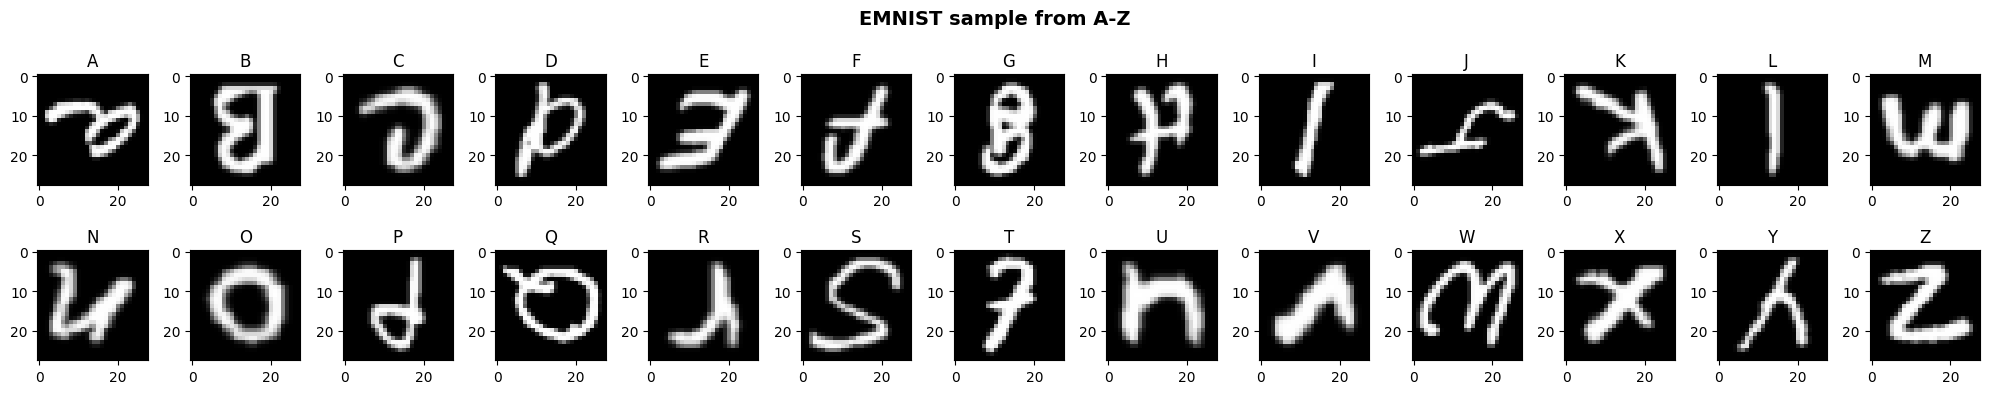

In [ ]:
fig, axes = plt.subplots(2, 13, figsize=(20, 4))

for cls in range(26):
    img = X[y == cls][0]           # take first letter from this line
    r, c = cls // 13, cls % 13    # calculate the position row and coloumn in this grid
    axes[r, c].imshow(img, cmap='gray')
    axes[r, c].set_title(chr(65 + cls), fontsize=12)

plt.suptitle('EMNIST sample from A-Z', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#4. FEAUTURE EXTRACTION
-Using Feature Extraction  
changing the HOG params :


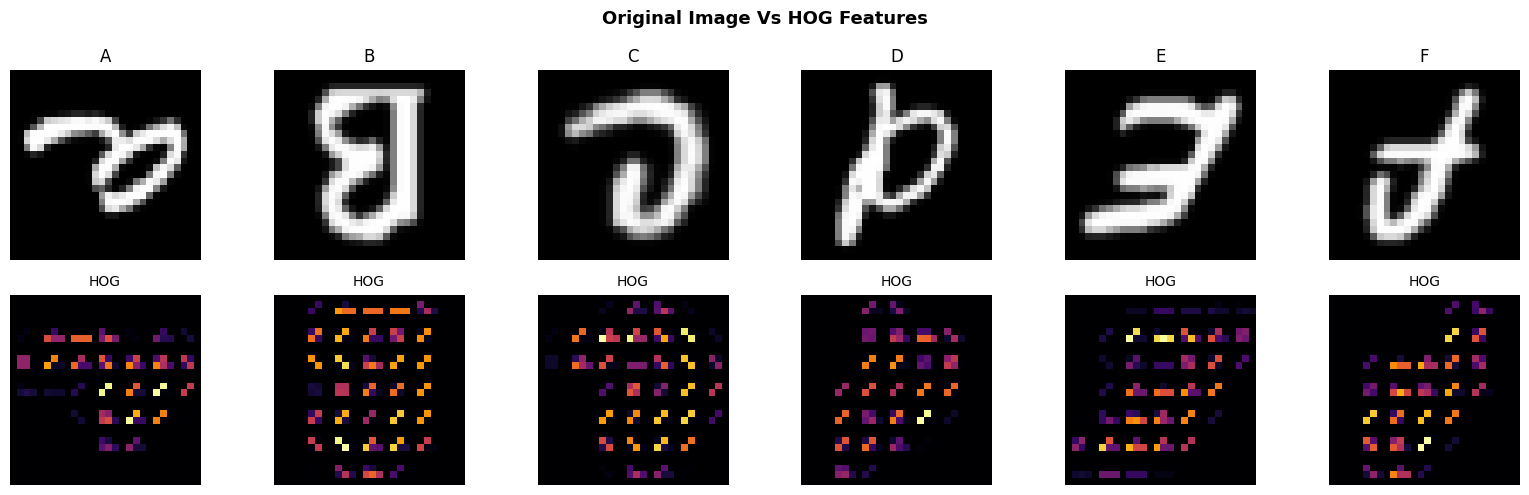

In [ ]:
HOG_PARAMS = {
    'orientations'   : 9,         #image divided by 9 gradien (0-180)
    'pixels_per_cell': (4, 4),    #every anylisis will be 4x4 pixsel
    'cells_per_block': (2, 2),    #cells per block
    'block_norm'     : 'L2-Hys',  #
}

#shows og image vs HOG image for the first 6 letter
#HOG image will look like a line sketch that shows corner of the letter
fig, axes = plt.subplots(2, 6, figsize=(16, 5))
for i in range(6):
    img = X[y == i][0]
    _, hog_img = hog(img, **HOG_PARAMS, visualize=True)
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(chr(65 + i), fontsize=12)
    axes[0, i].axis('off')
    axes[1, i].imshow(hog_img, cmap='inferno')
    axes[1, i].set_title('HOG', fontsize=10)
    axes[1, i].axis('off')
plt.suptitle('Original Image Vs HOG Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

-extract the HOG features from the 2.600 image

-the results X_hog, is the 2D array : 2600*1296


In [ ]:
X_hog = np.array([hog(img, **HOG_PARAMS) for img in X])
print(f'Shape fitur HOG: {X_hog.shape}  =>  {X_hog.shape[0]} gambar, {X_hog.shape[1]} fitur per gambar')

Shape fitur HOG: (2600, 1296)  =>  2600 gambar, 1296 fitur per gambar


#5. CLASSIFICATION
  Here we look for the best SVM param

In [ ]:
# list of the param combination that wil be used by Grid Search
# total : 2 kernel x 3 value of C x 2 values gamma = 12 combination
#every combination tests with 5-fold CV, so there will be 60 tme training process.

param_grid = {
    'kernel': ['rbf', 'poly'],   # rbf = radial basis function, for nonlinear image
    'C'     : [1, 10, 100],
    'gamma' : ['scale', 'auto']  # scale = count from total of features and data variables
}

#cv-5 is 5-fold cross validation
#training data divided by 5 equal value, and trained 5 times
gs = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print(f'\nBest Param : {gs.best_params_}')
print(f'Best CV Accuracy: {gs.best_score_*100:.2f}%')

best_svm = gs.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Param : {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 79.95%


-Evaluation of LOOCV (Leave-one-out cross validation)
  => after we know the best svm param, now we need to check out the model performance of all using LOOCV with 5-fold approaching.
  => all the 2.600 data will be split into 5 groups, model will be trained in 4 groupd and test in 1 group, do it 5 times until all data will be data test. the results will be on average to look for the best performance that is NOT bias.

In [ ]:
# combine train+test for the LOOCV of the 2600 data
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_res = cross_validate(
    best_svm, X_all, y_all, cv=cv,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    n_jobs=-1
)

#Matrics :
print('=== Hasil LOOCV (5-Fold) ===')
print(f'Accuracy  : {cv_res["test_accuracy"].mean()*100:.2f}%')
print(f'Precision : {cv_res["test_precision_macro"].mean()*100:.2f}%')
print(f'Recall    : {cv_res["test_recall_macro"].mean()*100:.2f}%')
print(f'F1-Score  : {cv_res["test_f1_macro"].mean()*100:.2f}%')

=== Hasil LOOCV (5-Fold) ===
Accuracy  : 81.46%
Precision : 82.27%
Recall    : 81.46%
F1-Score  : 81.45%


#6. CLASSIFICATION on test set + confusion matrix
  Lastly, we test the test set that is not seen for the whole training. and then there will be a confusion Matrix in the end where it shows the most frequent letter that is guessed wrong.(example the alphabet I is mostly known as L.

In [ ]:
y_pred = best_svm.predict(X_test)
labels_name = [chr(65 + i) for i in range(26)]

print('|Results in Test set (20%)')
print(f'Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'Precision : {precision_score(y_test, y_pred, average="macro")*100:.2f}%')
print(f'Recall    : {recall_score(y_test, y_pred, average="macro")*100:.2f}%')
print(f'F1-Score  : {f1_score(y_test, y_pred, average="macro")*100:.2f}%')
print()
print(classification_report(y_test, y_pred, target_names=labels_name))

|Results in Test set (20%)
Accuracy  : 81.92%
Precision : 82.39%
Recall    : 81.92%
F1-Score  : 81.59%

              precision    recall  f1-score   support

           A       0.75      0.90      0.82        20
           B       0.76      0.95      0.84        20
           C       0.86      0.90      0.88        20
           D       0.78      0.70      0.74        20
           E       0.81      0.65      0.72        20
           F       0.79      0.95      0.86        20
           G       0.64      0.35      0.45        20
           H       0.76      0.80      0.78        20
           I       0.82      0.70      0.76        20
           J       0.90      0.95      0.93        20
           K       0.68      0.75      0.71        20
           L       0.58      0.75      0.65        20
           M       0.78      0.90      0.84        20
           N       0.89      0.85      0.87        20
           O       1.00      0.95      0.97        20
           P       0.95      0.

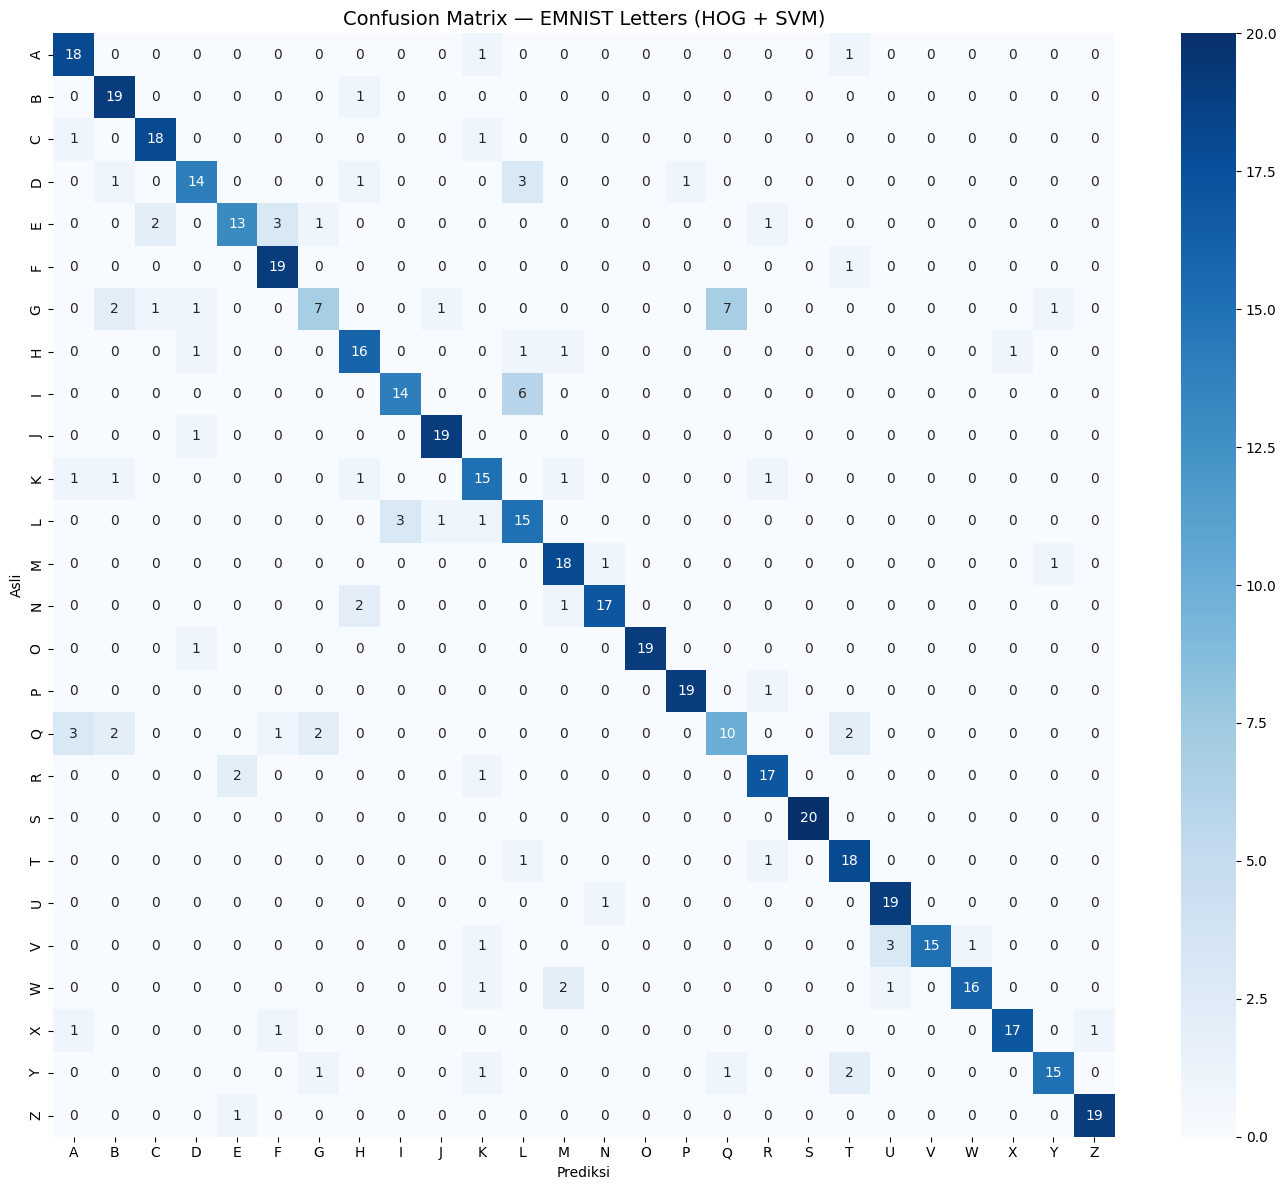

In [ ]:
#Confusion Matrix (heatmap)
#diagonally from left bellow to right bellow = the RIGHT prediction
#the box outside the diagonally = is WRONG prediction
#the more dark the colourouside the diagonal, that means the letter most likely to be wrong predict.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_name, yticklabels=labels_name)
plt.title('Confusion Matrix — EMNIST Letters (HOG + SVM)', fontsize=14)
plt.xlabel('Prediksi')
plt.ylabel('Asli')
plt.tight_layout()
plt.show()